<a href="https://colab.research.google.com/github/mousse-26/breast-cancer-ml-pipeline/blob/main/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML/data.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Reload the original dataframe to ensure 'diagnosis' column is in its original string format
df = pd.read_csv('/content/drive/MyDrive/ML/data.csv')

# Drop unnecessary columns, ignore if not found
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')

# Ensure diagnosis column is string type and then encode
df['diagnosis'] = df['diagnosis'].astype(str)
df['diagnosis'] = np.where(df['diagnosis'] == 'M', 1, 0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9736842105263158
F1 Score: 0.9647058823529412
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



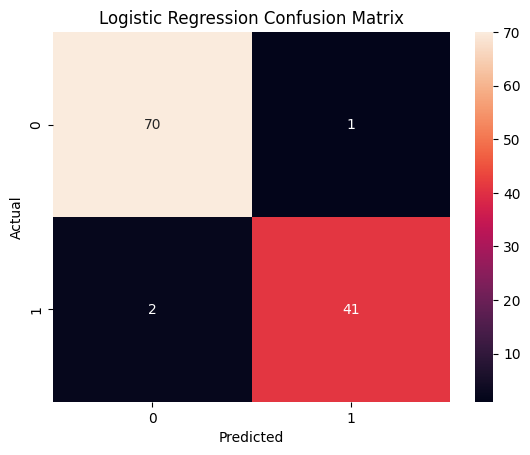

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
for depth in [3, 4, 5]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    print(f"Depth {depth} Accuracy:", dt_temp.score(X_test, y_test))

Depth 3 Accuracy: 0.9473684210526315
Depth 4 Accuracy: 0.9473684210526315
Depth 5 Accuracy: 0.9473684210526315


In [ ]:
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9385964912280702
F1 Score: 0.9156626506024096
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        71
           1       0.95      0.88      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
concave points_mean,0.723079
concave points_worst,0.068657
radius_worst,0.054694
perimeter_worst,0.053852
texture_worst,0.035313
texture_mean,0.028936
fractal_dimension_se,0.012841
area_se,0.012531
texture_se,0.010097
area_mean,0.000000


In [ ]:
rules = export_text(dt, feature_names=list(X.columns))
print(rules)

|--- concave points_mean <= 0.06
|   |--- radius_worst <= 0.12
|   |   |--- area_se <= 0.18
|   |   |   |--- texture_worst <= 2.18
|   |   |   |   |--- class: 0
|   |   |   |--- texture_worst >  2.18
|   |   |   |   |--- class: 0
|   |   |--- area_se >  0.18
|   |   |   |--- class: 1
|   |--- radius_worst >  0.12
|   |   |--- texture_mean <= -0.72
|   |   |   |--- class: 0
|   |   |--- texture_mean >  -0.72
|   |   |   |--- texture_se <= 0.29
|   |   |   |   |--- class: 1
|   |   |   |--- texture_se >  0.29
|   |   |   |   |--- class: 0
|--- concave points_mean >  0.06
|   |--- concave points_worst <= 0.49
|   |   |--- perimeter_worst <= 0.24
|   |   |   |--- texture_worst <= 0.29
|   |   |   |   |--- class: 0
|   |   |   |--- texture_worst >  0.29
|   |   |   |   |--- class: 1
|   |   |--- perimeter_worst >  0.24
|   |   |   |--- class: 1
|   |--- concave points_worst >  0.49
|   |   |--- fractal_dimension_se <= 3.21
|   |   |   |--- class: 1
|   |   |--- fractal_dimension_se >  3.21


In [ ]:
best_k = 0
best_score = 0

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)

    print(f"k = {k}, Accuracy = {score}")

    if score > best_score:
        best_score = score
        best_k = k

print("Best k:", best_k)

k = 1, Accuracy = 0.9385964912280702
k = 3, Accuracy = 0.9473684210526315
k = 5, Accuracy = 0.9473684210526315
k = 7, Accuracy = 0.9473684210526315
k = 9, Accuracy = 0.9649122807017544
Best k: 9


In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("kNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

kNN
Accuracy: 0.9649122807017544
F1 Score: 0.9534883720930233
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9649122807017544
F1 Score: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.956140350877193
F1 Score: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "kNN", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.973684,0.964706
1,Decision Tree,0.938596,0.915663
2,kNN,0.964912,0.953488
3,Random Forest,0.964912,0.952381
4,Gradient Boosting,0.956140,0.941176
